In [1]:
%load_ext autoreload
%autoreload 2
    
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from torch.utils.data import TensorDataset, DataLoader

import sys
from pathlib import Path

parent_dir = Path.cwd().parent
sys.path.append(str(parent_dir))

from models.mlp import MLP_1, MLP_2

Load and split a dataset with Morgan fingerprints (and activities)

In [2]:
activity = np.loadtxt("../data_collection/activity.dat")
activity = activity.reshape(-1, 1)
indices = range(len(activity))

ind_train, ind_val = train_test_split(
    indices,
    test_size=0.10,
    random_state=42
)

act_train, act_val = activity[ind_train], activity[ind_val]

fp = np.loadtxt("../data_collection/fp_only.dat")
fp = np.log1p(fp)

fp_train, fp_val = fp[ind_train], fp[ind_val]

print(fp_train.shape, act_train.shape)

device = torch.device("cpu")
#np.random.seed(42)
#torch.manual_seed(42)

(7402, 2048) (7402, 1)


Train a custom MLP model (see ../models/mlp.py) to predict activity values on Morgan fingerprints 

In [3]:
dataset_train = TensorDataset(torch.tensor(fp_train, dtype=torch.float32), torch.tensor(act_train, dtype=torch.float32))
dataset_val = TensorDataset(torch.tensor(fp_val, dtype=torch.float32), torch.tensor(act_val, dtype=torch.float32))

train_loader = DataLoader(
    dataset_train, 
    batch_size=100,   
    shuffle=True   
)

val_loader = DataLoader(
    dataset_val, 
    batch_size=len(dataset_val),   
    shuffle=True     
)

epochs = 100
model = MLP_1(fp_train.shape[1], 256, 128, 16, 1).to(device)
model.fit(train_loader, val_loader, device, epochs=epochs)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:25<00:00,  3.92it/s]


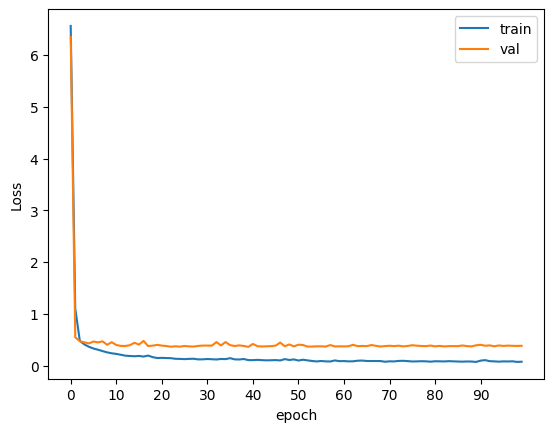

R² Train Score: 0.964
Train RMSE:     ±0.189
Train MAE:      ±0.114
R² Val Score: 0.663
Val RMSE:     ±0.578
Val MAE:      ±0.428


In [4]:
plt.plot(model.train_loss, label='train')
plt.plot(model.val_loss, label='val')

plt.legend()
plt.xlabel('epoch')
plt.ylabel('Loss')
plt.xticks(range(0, epochs, 10))
plt.show()

model.eval()
model.analysis(fp_train, act_train, fp_val, act_val, device)

Load and split a dataset with molecular descriptors (and activities)

In [5]:
mol_desc = np.loadtxt("../data_collection/mol_desc.dat")

mol_desc_train, mol_desc_val = mol_desc[ind_train], mol_desc[ind_val]

scaler = StandardScaler()
mol_desc_train = scaler.fit_transform(mol_desc_train)
mol_desc_val = scaler.transform(mol_desc_val)

Train the custom MLP model (see ../models/mlp.py) to predict activity values on molecular descriptors 

In [6]:
dataset_train = TensorDataset(torch.tensor(mol_desc_train, dtype=torch.float32), torch.tensor(act_train, dtype=torch.float32))
dataset_val = TensorDataset(torch.tensor(mol_desc_val, dtype=torch.float32), torch.tensor(act_val, dtype=torch.float32))

train_loader = DataLoader(
    dataset_train, 
    batch_size=100,   
    shuffle=True   
)

val_loader = DataLoader(
    dataset_val, 
    batch_size=len(dataset_val),   
    shuffle=True     
)

epochs = 100
model = MLP_1(mol_desc_train.shape[1], 256, 128, 16, 1).to(device)
model.fit(train_loader, val_loader, device, epochs=epochs)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:08<00:00, 11.26it/s]


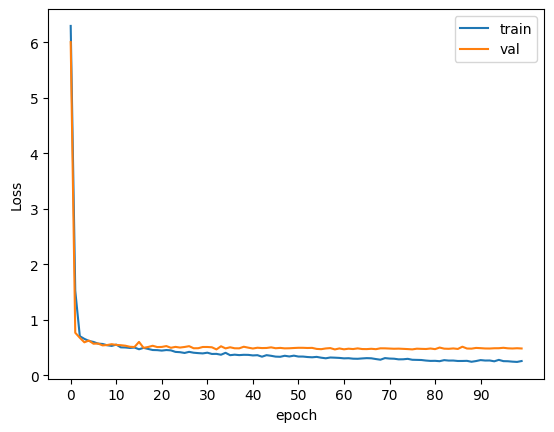

R² Train Score: 0.838
Train RMSE:     ±0.404
Train MAE:      ±0.274
R² Val Score: 0.497
Val RMSE:     ±0.706
Val MAE:      ±0.531


In [7]:
plt.plot(model.train_loss, label='train')
plt.plot(model.val_loss, label='val')

plt.legend()
plt.xlabel('epoch')
plt.ylabel('Loss')
plt.xticks(range(0, epochs, 10))
plt.show()

model.eval()
model.analysis(mol_desc_train, act_train, mol_desc_val, act_val, device)

Combine molecular descriptors and Morgan fingerprints and train the custom MLP model (see ../models/mlp.py) to predict activity values on this combined dataset

In [8]:
full_mol_rep_train = np.hstack([fp_train, mol_desc_train])
full_mol_rep_val = np.hstack([fp_val, mol_desc_val])

dataset_train = TensorDataset(torch.tensor(full_mol_rep_train, dtype=torch.float32), torch.tensor(act_train, dtype=torch.float32))
dataset_val = TensorDataset(torch.tensor(full_mol_rep_val, dtype=torch.float32), torch.tensor(act_val, dtype=torch.float32))

train_loader = DataLoader(
    dataset_train, 
    batch_size=100,   
    shuffle=True   
)

val_loader = DataLoader(
    dataset_val, 
    batch_size=len(dataset_val),   
    shuffle=True     
)

epochs = 100
model = MLP_1(full_mol_rep_train.shape[1], 256, 128, 16, 1).to(device)
model.fit(train_loader, val_loader, device, epochs=epochs)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:25<00:00,  3.90it/s]


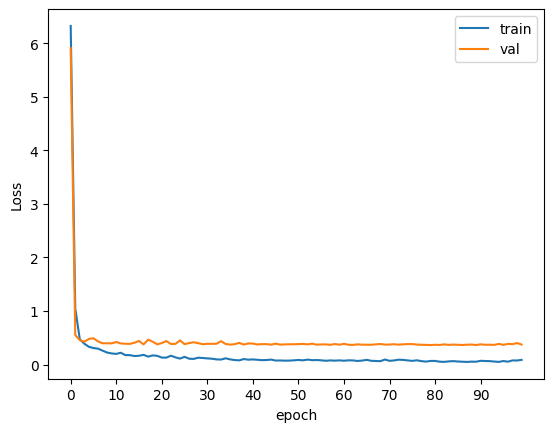

R² Train Score: 0.981
Train RMSE:     ±0.140
Train MAE:      ±0.102
R² Val Score: 0.698
Val RMSE:     ±0.548
Val MAE:      ±0.419


In [9]:
plt.plot(model.train_loss, label='train')
plt.plot(model.val_loss, label='val')

plt.legend()
plt.xlabel('epoch')
plt.ylabel('Loss')
plt.xticks(range(0, epochs, 10))
plt.show()

model.eval()
model.analysis(full_mol_rep_train, act_train, full_mol_rep_val, act_val, device)

Train the second custom MLP model (see ../models/mlp.py) to predict activity values on the combined dataset. The second model processes Morgan fingerprints and molecular descriptors through distinct feature branches first, then merges them to predict activity.

In [36]:
dataset_train = TensorDataset(torch.tensor(fp_train, dtype=torch.float32),
                              torch.tensor(mol_desc_train, dtype=torch.float32),
                              torch.tensor(act_train, dtype=torch.float32))
dataset_val = TensorDataset(torch.tensor(fp_val, dtype=torch.float32),
                            torch.tensor(mol_desc_val, dtype=torch.float32), 
                            torch.tensor(act_val, dtype=torch.float32))

train_loader = DataLoader(
    dataset_train, 
    batch_size=100,   
    shuffle=True   
)

val_loader = DataLoader(
    dataset_val, 
    batch_size=len(dataset_val),   
    shuffle=True     
)

epochs = 100
model = MLP_2((fp_train.shape[1], 256, 128, 16), (mol_desc_train.shape[1], 256, 128, 16), (8, 1)).to(device)
model.fit(train_loader, val_loader, device, epochs=epochs)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:35<00:00,  2.78it/s]


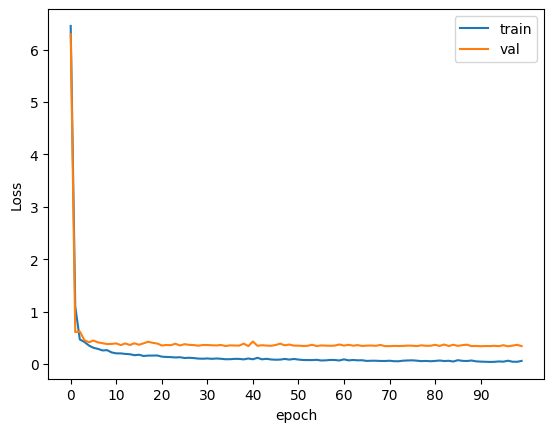

R² Train Score: 0.985
Train RMSE:     ±0.123
Train MAE:      ±0.076
R² Val Score: 0.728
Val RMSE:     ±0.519
Val MAE:      ±0.387


In [37]:
plt.plot(model.train_loss, label='train')
plt.plot(model.val_loss, label='val')

plt.legend()
plt.xlabel('epoch')
plt.ylabel('Loss')
plt.xticks(range(0, epochs, 10))
plt.show()

model.eval()

pred = model(torch.tensor(fp_train, dtype=torch.float32).to(device), torch.tensor(mol_desc_train, dtype=torch.float32).to(device))
pred = pred.cpu().detach().numpy()

r2 = r2_score(act_train, pred)
rmse = np.sqrt(mean_squared_error(act_train, pred))
mae = mean_absolute_error(act_train, pred)

print(f"R² Train Score: {r2:.3f}")
print(f"Train RMSE:     ±{rmse:.3f}")
print(f"Train MAE:      ±{mae:.3f}")

pred = model(torch.tensor(fp_val, dtype=torch.float32).to(device), torch.tensor(mol_desc_val, dtype=torch.float32).to(device))
pred = pred.cpu().detach().numpy()

r2 = r2_score(act_val, pred)
rmse = np.sqrt(mean_squared_error(act_val, pred))
mae = mean_absolute_error(act_val, pred)

print(f"R² Val Score: {r2:.3f}")
print(f"Val RMSE:     ±{rmse:.3f}")
print(f"Val MAE:      ±{mae:.3f}")